In [3]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.offline as pyo

pyo.init_notebook_mode(connected = True)
pd.options.plotting.backend = 'plotly'

In [5]:
portfolio = ['HDFCBANK.NS', 'TCS.NS', 'RELIANCE.NS', 'GC=F', '^NSEI']
portfolio

['HDFCBANK.NS', 'TCS.NS', 'RELIANCE.NS', 'GC=F', '^NSEI']

In [7]:
df = yf.download(portfolio, start='2015-01-01', end='2026-01-30')['Close']
df

[*********************100%***********************]  5 of 5 completed


Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Date,,,,,
2015-01-01,NaN,217.235367,189.999802,988.879517,NaN
2015-01-02,1186.000000,220.258682,189.496918,1002.048889,8395.450195
2015-01-05,1203.900024,218.399063,187.421280,986.820679,8378.400391
2015-01-06,1219.300049,214.999222,178.915237,950.440430,8127.350098
2015-01-07,1210.599976,215.626709,182.809784,939.213562,8102.100098
...,...,...,...,...,...
2026-01-23,4976.200195,916.099976,1386.099976,3162.500000,25048.650391
2026-01-26,5079.700195,NaN,NaN,NaN,NaN
2026-01-27,5079.899902,926.400024,1380.500000,3158.000000,25175.400391


In [11]:
log_returns = np.log(df/df.shift(1)).dropna()
log_returns

Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Date,,,,,
2015-01-05,0.014980,-0.008479,-0.011014,-0.015314,-0.002033
2015-01-06,0.012711,-0.015690,-0.046447,-0.037563,-0.030422
2015-01-07,-0.007161,0.002914,0.021534,-0.011883,-0.003112
2015-01-08,-0.001819,0.020788,-0.014443,0.010737,0.016221
2015-01-09,0.006270,0.011131,0.021442,0.027645,0.006042
...,...,...,...,...,...
2026-01-21,0.015055,-0.011720,0.007575,0.006522,-0.002977
2026-01-22,0.015810,-0.001794,-0.001496,0.008863,0.005249
2026-01-23,0.013637,-0.002834,-0.011762,0.003833,-0.009585


In [13]:
monthly_returns = log_returns.resample('ME').last()
monthly_returns

Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Date,,,,,
2015-01-31,0.018871,-0.016250,-0.015342,-0.024908,-0.016153
2015-02-28,0.002477,0.015152,0.015964,0.002219,0.018342
2015-03-31,-0.001436,-0.013789,0.018635,-0.003985,-0.000153
2015-04-30,-0.022909,-0.004390,0.014425,-0.009533,-0.007094
2015-05-31,0.001094,0.020338,0.001369,0.000307,0.013688
...,...,...,...,...,...
2025-09-30,0.005195,0.000736,-0.006431,-0.002662,-0.000967
2025-10-31,-0.004785,-0.010930,-0.001412,0.007451,-0.006037
2025-11-30,0.006262,0.014145,0.019424,0.013913,0.012306


In [15]:
monthly_returns.cov()

Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Ticker,,,,,
GC=F,0.000095,0.000003,-0.000004,0.000019,0.000011
HDFCBANK.NS,0.000003,0.000176,0.000088,0.000063,0.000090
RELIANCE.NS,-0.000004,0.000088,0.000296,0.000091,0.000116
TCS.NS,0.000019,0.000063,0.000091,0.000230,0.000105
^NSEI,0.000011,0.000090,0.000116,0.000105,0.000108


The covariance and variance of the stock in diagonal gonna be same

In [17]:
monthly_returns.var()

Ticker
GC=F           0.000095
HDFCBANK.NS    0.000176
RELIANCE.NS    0.000296
TCS.NS         0.000230
^NSEI          0.000108
dtype: float64

In [20]:
monthly_returns.corr()

Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Ticker,,,,,
GC=F,1.000000,0.025000,-0.021816,0.131486,0.110172
HDFCBANK.NS,0.025000,1.000000,0.384410,0.311461,0.651965
RELIANCE.NS,-0.021816,0.384410,1.000000,0.347226,0.649223
TCS.NS,0.131486,0.311461,0.347226,1.000000,0.665569
^NSEI,0.110172,0.651965,0.649223,0.665569,1.000000


<Axes: xlabel='Ticker', ylabel='Ticker'>

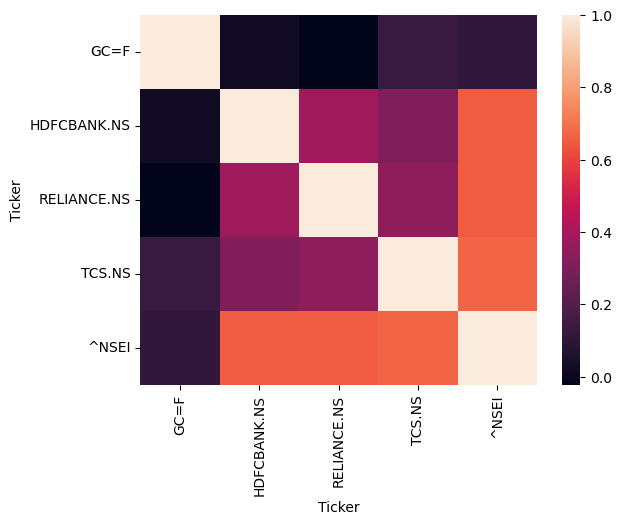

In [24]:
sns.heatmap(monthly_returns.corr())

We don't want our stock to be perfectly correlated. If they are perfectly correlated then it will not provide dowside protection from uncertainity